# Project Bimbingan Karir Data Science

### Table of Contents
* [1) Pengumpulan Data](#h1)
* [2) Menelaah Data](#h2)
* [3) Validasi Data](#h3)
* [4) Menetukan Object Data](#h4)
* [5) Membersihkan Data](#h5)
* [6) Konstruksi Data](#h6)
* [7) Menentukan label data](#h7)
* [8) Modelling](#h8)
* [9) Evaluasi](#h9)


## 1) Pengumpulan Data <a class="anchor" id="h1"></a>

Dataset yang digunakan adalah dataset yang bersumber dari link berikut : https://www.kaggle.com/datasets/aadarshvelu/aids-virus-infection-prediction

Dataset yang dipakai adalah dataset dengan nama file "AIDS_Classification.csv". diharapkan sebelum memakai dataset tersebut Anda dapat membaca deskripsi, konteks, beserta informasi atribut dataset pada tautan tersebut.

Tentang Dataset

Konteks:
Dataset ini berisi statistik kesehatan dan informasi kategorikal tentang pasien yang telah didiagnosis dengan AIDS. Dataset ini pertama kali dipublikasikan pada tahun 1996.
Informasi Atribut:

time: waktu hingga kegagalan atau penyensoran

trt: indikator pengobatan (0 = ZDV saja; 1 = ZDV + ddI; 2 = ZDV + Zal; 3 = ddI saja)

age: usia (tahun) saat baseline

wtkg: berat badan (kg) saat baseline

hemo: hemofilia (0=Tidak, 1=Ya)

homo: aktivitas homoseksual (0=Tidak, 1=Ya)

drugs: riwayat penggunaan obat IV (0=Tidak, 1=Ya)

karnof: skor Karnofsky (pada skala 0-100)

oprior: terapi antiretroviral non-ZDV pre-175 (0=Tidak, 1=Ya)

z30: ZDV dalam 30 hari sebelum t175 (0=Tidak, 1=Ya)

preanti: hari terapi anti-retroviral pre-175

race: ras (0=Putih, 1=non-putih)

gender: jenis kelamin (0=P, 1=L)

str2: riwayat antiretroviral (0=naif, 1=berpengalaman)

strat: stratifikasi riwayat antiretroviral (0=Antiretroviral Naif; 2=> 1 tapi <= 52 minggu terapi antiretroviral sebelumnya; 3=> 52 minggu)
symptom: indikator simtomatik (0=asimpt, 1=simp)

treat: indikator pengobatan (0=ZDV saja, 1=lainnya)

offtrt: indikator off-trt sebelum 96+/-5 minggu (0=Tidak,1=Ya)

cd40: CD4 saat baseline

cd420: CD4 pada 20+/-5 minggu

cd80: CD8 saat baseline

cd820: CD8 pada 20+/-5 minggu

infected: terinfeksi AIDS (0=Tidak, 1=Ya)

Informasi Variabel Tambahan:

Informasi pribadi (usia, berat badan, ras, jenis kelamin, aktivitas seksual)

Riwayat medis (hemofilia, riwayat penggunaan obat IV)

Riwayat pengobatan (riwayat pengobatan ZDV/non-ZDV)

Hasil laboratorium (hitungan CD4/CD8)

## 2) Menelaah Data <a class="anchor" id="h2"></a>

pilih dan masukan library yang anda butuhkan untuk menelaah data

In [ ]:
import numpy as np # untuk komputasi numerik (matematika, array, statistik).
import pandas as pd # untuk manipulasi dan analisis data dalam format tabel.

# Menampilkan semua kolom dari dataframe saat mencetak dataframe
pd.set_option("display.max_columns", None)

### Load Data

masukkan dataset yang dibutuhkan dengan alamat penyimpanan yang tepat dan simpan kedalam sebuah variabel

In [ ]:
# Menyambungkan google colab dengan google drive untuk memasukkan dataset
#from google.colab import drive # library untuk mengakses Google Drive dari Google Colab.
#drive.mount('/content/drive') # mount Google Drive agar file di dalamnya dapat diakses.

In [ ]:
# Mengecek file dalam directory
#!ls "/content/drive/My Drive/Dataset/AIDS_Classification.csv" # menampilkan daftar file/direktori untuk memastikan file tersedia

In [ ]:
# dir adalah variabel yang digunakan untuk menyimpan data dengan path yang ada google drive saya
#dir =  '/content/drive/My Drive/Dataset/AIDS_Classification.csv' # menyimpan path file dataset untuk kemudahan akses di kode berikutnya.

Baca dataset csv dengan library pandas

In [ ]:
# Membaca dan menampilkan dataset
data = pd.read_csv('/content/AIDS_Classification.csv') # membaca file CSV dari path yang telah didefinisikan sebelumnya.
data.head() # Menampilkan data 5 baris pertama dataset untuk melihat struktur data.

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [ ]:
data.tail() # Menampilkan data 5 baris terakhir dataset.

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
2134,1091,3,21,53.2980,1,0,0,100,0,1,842,0,1,1,3,0,1,1,152,109,561,720,0
2135,395,0,17,102.9672,1,0,0,100,0,1,417,1,1,1,3,0,0,1,373,218,1759,1030,0
2136,1104,2,53,69.8544,1,1,0,90,0,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0
2137,465,0,14,60.0000,1,0,0,100,0,0,0,0,1,0,1,0,0,0,166,169,999,1838,1
2138,1045,3,45,77.3000,1,0,0,100,0,0,0,0,1,0,1,0,1,0,911,930,885,526,0


menampilan informasi dari file dataset yang sudah dimasukkan kedalam dataframe

In [ ]:
# Informasi dataset
data.info() # memberikan ringkasan struktur dataset, termasuk tipe data dan jumlah nilai kosong

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      2139 non-null   int64  
 1   trt       2139 non-null   int64  
 2   age       2139 non-null   int64  
 3   wtkg      2139 non-null   float64
 4   hemo      2139 non-null   int64  
 5   homo      2139 non-null   int64  
 6   drugs     2139 non-null   int64  
 7   karnof    2139 non-null   int64  
 8   oprior    2139 non-null   int64  
 9   z30       2139 non-null   int64  
 10  preanti   2139 non-null   int64  
 11  race      2139 non-null   int64  
 12  gender    2139 non-null   int64  
 13  str2      2139 non-null   int64  
 14  strat     2139 non-null   int64  
 15  symptom   2139 non-null   int64  
 16  treat     2139 non-null   int64  
 17  offtrt    2139 non-null   int64  
 18  cd40      2139 non-null   int64  
 19  cd420     2139 non-null   int64  
 20  cd80      2139 non-null   int6

Mendapatkan informasi pada dataset seperti mean, standar deviasi, modus, min, max

In [ ]:
data.describe().T # memberikan statistik deskriptif dataset (mean, std, min, dll.) dan ditranspos (T) agar lebih mudah dibaca

,count,mean,std,min,25%,50%,75%,max
time,2139.0,879.098177,292.274324,14.0,727.0000,997.0000,1091.0000,1231.00000
trt,2139.0,1.520804,1.127890,0.0,1.0000,2.0000,3.0000,3.00000
age,2139.0,35.248247,8.709026,12.0,29.0000,34.0000,40.0000,70.00000
wtkg,2139.0,75.125311,13.263164,31.0,66.6792,74.3904,82.5552,159.93936
hemo,2139.0,0.084151,0.277680,0.0,0.0000,0.0000,0.0000,1.00000
homo,2139.0,0.661057,0.473461,0.0,0.0000,1.0000,1.0000,1.00000
drugs,2139.0,0.131370,0.337883,0.0,0.0000,0.0000,0.0000,1.00000
karnof,2139.0,95.446470,5.900985,70.0,90.0000,100.0000,100.0000,100.00000
oprior,2139.0,0.021973,0.146629,0.0,0.0000,0.0000,0.0000,1.00000
z30,2139.0,0.550257,0.497584,0.0,0.0000,1.0000,1.0000,1.00000


## 3) Validasi Data <a class="anchor" id="h3"></a>
Beberapa fungsi telah tersedia untuk membantumu eksplorasi dataset, deskripsikan temuanmu pada cell Essay!

Pada tahap ini bertujuan untuk mengetahui dan memahami isi dari dataset agar dapat dilakukan penanganan sesuai dengan kondisinya.

In [ ]:
import matplotlib.pyplot as plt # visualisasi data (grafik dasar seperti garis, batang).
import seaborn as sns # visualisasi statistik yang lebih menarik dan informatif.

Membuat fungsi untuk memecah variable kategori dan numerik

In [ ]:
data.rename(columns={
    'trt': 'treatment_indicator',  # More descriptive
    'age': 'age',
    'wtkg': 'weight_at_kg',
    'hemo': 'hemophilia',
    'homo': 'homosexual_activity',
    'drugs': 'drug_use_history',
    'karnof': 'karnofsky_score',
    'oprior': 'prior_non_zdv_therapy', # clarified
    'z30': 'zdv_in_last_30_days',
    'preanti': 'days_prior_anti_retroviral_therapy',
    'race': 'race',
    'gender': 'gender',
    'str2': 'antiretroviral_history',
    'strat': 'antiretroviral_history_stratification',
    'symptom': 'symptomatic_indicator',
    'treat': 'treatment', # Differentiating from 'trt'
    'offtrt': 'off_treatment_before_96_weeks',
    'cd40': 'cd4_at_baseline',
    'cd420': 'cd4_at_20_weeks',
    'cd80': 'cd8_at_baseline',
    'cd820': 'cd8_at_20_weeks',
}, inplace=True)

In [ ]:
# Mengidentifikasi jenis kolom (variabel) dalam sebuah dataframe berdasarkan tipe data dan karakteristiknya

def grab_col_names(dataframe, cat_th = 10, car_th = 20): #  memisahkan kolom dalam dataset berdasarkan tipe dan karakteristiknya.

    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]] # kolom kategorikal (tipe "category", "object", "bool", atau numerik dengan unique values < cat_th).
    num_but_cat = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["int64", "float64"] and dataframe[col].nunique() < cat_th] # kolom numerik yang bertindak seperti kategorikal (berdasarkan jumlah unique values).
    cat_but_car = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object"] and dataframe[col].nunique() > car_th] # kolom kategorikal dengan unique values > car_th (high cardinality).

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # kolom numerik murni (int64, float64) yang bukan kategorikal.
    num_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["int64", "float64"]]

    print(f"Jumlah observasi: {dataframe.shape[0]}")
    print(f"Jumlah variabel: {dataframe.shape[1]}")
    print(f"Kolom kategorikal: {len(cat_cols)}")
    print(f"Kolom Numerik: {len([col for col in num_cols if col not in cat_cols])}")
    print(f"Kategori tapi kardinal: {len(cat_but_car)}")
    print(f"Numerik tapi kategorikal: {len(num_but_cat)}")

    # mengembalikan daftar kolom yang dikelompokkan berdasarkan tipe (cat_cols,
    # num_cols, cat_but_car).
    return cat_cols, [col for col in num_cols if col not in cat_cols], cat_but_car

Membuat fungsi untuk menampilkan visual berdasarkan variabel kategori

In [ ]:
# Memvisualisasikan distribusi kolom-kolom kategorikal dalam sebuah dataframe menggunakan dua jenis plot: countplot dan pie plot
def plot_categorical(dataframe, categorical_columns): # membuat visualisasi untuk kolom kategorikal dalam dataset.
    num_cols = len(categorical_columns) # daftar kolom kategorikal yang akan divisualisasikan.
    num_rows = num_cols
    fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_columns):
        # Countplot: Membuat countplot untuk distribusi jumlah kategori.
        sns.countplot(x=col, data=dataframe, ax=axes[2*i], hue=col) # menunjukkan jumlah observasi dalam setiap kategori menggunakan bar chart.
        axes[2*i].set_title(f'{col} Count')
        axes[2*i].set_xlabel(col)
        axes[2*i].set_ylabel('Count')

        # Pieplot: Membuat pieplot untuk distribusi proporsi kategori.
        dataframe[col].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2*i+1]) # menampilkan proporsi kategori dalam bentuk diagram lingkaran.
        axes[2*i+1].set_title(f'{col} Distribution')
        axes[2*i+1].set_ylabel('')

    # Menyesuaikan layout dengan plt.tight_layout() untuk hasil visualisasi yang rapi.
    plt.tight_layout()
    plt.show()

Analisa variabel numerik

In [ ]:
# Membuat histogram bagi setiap kolom numerik dalam sebuah dataframe
def plot_histograms(dataframe, numeric_columns): # membuat histogram untuk setiap kolom numerik dalam dataset.

    num_cols = len(numeric_columns) # daftar kolom numerik yang akan divisualisasikan.
    num_rows = (num_cols + 1) // 4 + ((num_cols + 1) % 4 != 0)
    fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_columns):
        dataframe[col].hist(ax=axes[i], bins=20)  # Untuk mengurangi ukurannya, kami mengurangi nilai tempat sampah.
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    for j in range(num_cols, num_rows * 4):
        fig.delaxes(axes[j])  # Jika jumlah kolom tidak habis dibagi 4, hapus sumbu yang berlebihan

    # menampilkan histogram frekuensi untuk setiap kolom numerik.
    plt.tight_layout()
    plt.show()

In [ ]:
# Menganalisis hubungan antara kolom kategorikal dengan target (variabel dependen) dalam sebuah dataframe, dan menyajikan hasilnya dalam bentuk tabel dan visualisasi bar chart
def target_summary_with_cat_visualized(dataframe, target, categorical_col):
    # Rata-rata nilai target dihitung untuk setiap kategori
    grouped_data = dataframe.groupby(categorical_col)[target].mean()

    # Membuat Dataframe dari Hasil Pengelompokan
    summary_df = pd.DataFrame({"TARGET_MEAN": grouped_data})

    # Visualisasi dengan Bar Chart
    plt.figure(figsize=(5, 5))
    summary_df.plot(kind='bar')
    plt.title('Mean Target by ' + categorical_col)
    plt.xlabel(categorical_col)
    plt.ylabel('Mean Target')
    plt.xticks(rotation=1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}))
    print("-"*50)

Target analisa variabel degnan variabel numerik

In [ ]:
# Menganalisis hubungan antara kolom target (kategorikal) dengan kolom numerik dalam sebuah dataframe
def target_summary_with_num_visualized(dataframe, target, numerical_col):
    # Hitung rata-rata dari kolom numerik untuk setiap kategori variabel target
    grouped_data = dataframe.groupby(target)[numerical_col].mean()

    # Membuat diagram batang untuk memvisualisasikan data
    plt.figure(figsize=(5, 5))
    grouped_data.plot(kind='bar', color='skyblue')
    plt.title('Mean ' + numerical_col + ' by ' + target)
    plt.xlabel(target)
    plt.ylabel('Mean ' + numerical_col)
    plt.xticks(rotation=1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(dataframe.groupby(target).agg({numerical_col: "mean"}))
    print("-"*50)

Analisa Outlier untuk mengetahui data yang tidak sesuai

In [ ]:
# Membuat visualisasi boxplot (diagram kotak) untuk semua kolom numerik yang diberikan
def boxplot(dataframe, numeric_columns):
    num_plots = len(numeric_columns)
    num_rows = (num_plots + 3) // 4 #Menghitung Jumlah Baris Grafik
    fig, axes = plt.subplots(num_rows, 4, figsize=(18, 4*num_rows)) # Membuat grid subplots dengan ukuran yang sesuai
    for i, column in enumerate(numeric_columns):
        row = i // 4
        col = i % 4
        sns.boxplot(y=dataframe[column], ax=axes[row, col]) # Iterasi Kolom Numerik untuk Membuat Boxplot
        axes[row, col].set_title(f'Boxplot of {column}')
        axes[row, col].set_ylabel(column)

    # Penentuan posisi subplot dalam grid
    for j in range(num_plots, num_rows*4):
        row = j // 4
        col = j % 4
        fig.delaxes(axes[row, col]) # Menghapus Grafik Kosong

    # Penyesuaian Layout
    plt.tight_layout()
    plt.show()

In [ ]:
grouped_infect = data.groupby("infected")["infected"].count().reset_index(name="counts")

<ipython-input-59-7c0885f6d941>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped_infect.infected, y=grouped_infect.counts, palette=["#008b8b", "#8b636c"])


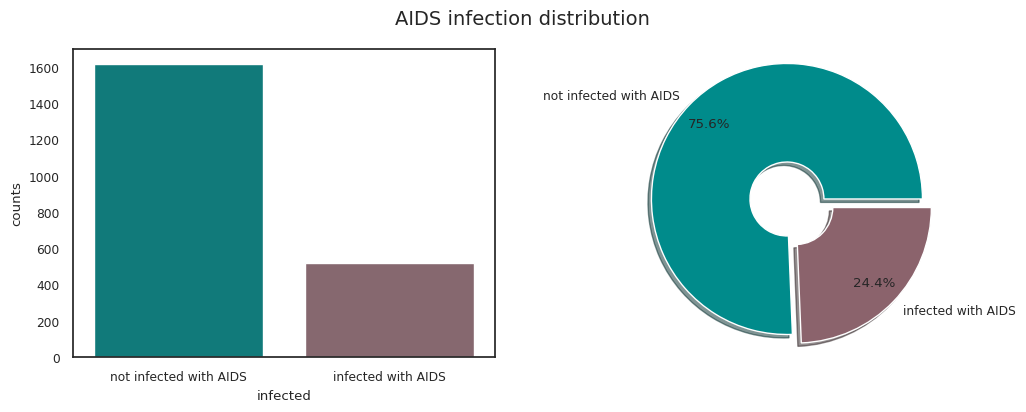

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.barplot(x=grouped_infect.infected, y=grouped_infect.counts, palette=["#008b8b", "#8b636c"])
plt.xticks(ticks=(0,1), labels=["not infected with AIDS", "infected with AIDS"])
plt.subplot(1,2,2)
plt.pie(x=grouped_infect.counts, shadow=True, autopct="%.1f%%", pctdistance=0.8,
        labels=["not infected with AIDS", "infected with AIDS"], colors=["#008b8b", "#8b636c"],
        radius=1.4-0.3, wedgeprops=dict(width=0.8), explode= [0.05,0.05])
plt.suptitle("AIDS infection distribution", fontsize=14)
plt.show()


<ipython-input-60-e3730852110d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data[col].value_counts().index, y=data[col].value_counts(), palette=clr)
<ipython-input-60-e3730852110d>:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(x=data[col].value_counts().index, y=data[col].value_counts(), palette=clr)
<ipython-input-60-e3730852110d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data[col].value_counts().index, y=data[col].value_counts(), palette=clr)
<ipython-input-60-e3730852110d>:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(x=data[col].value_counts(

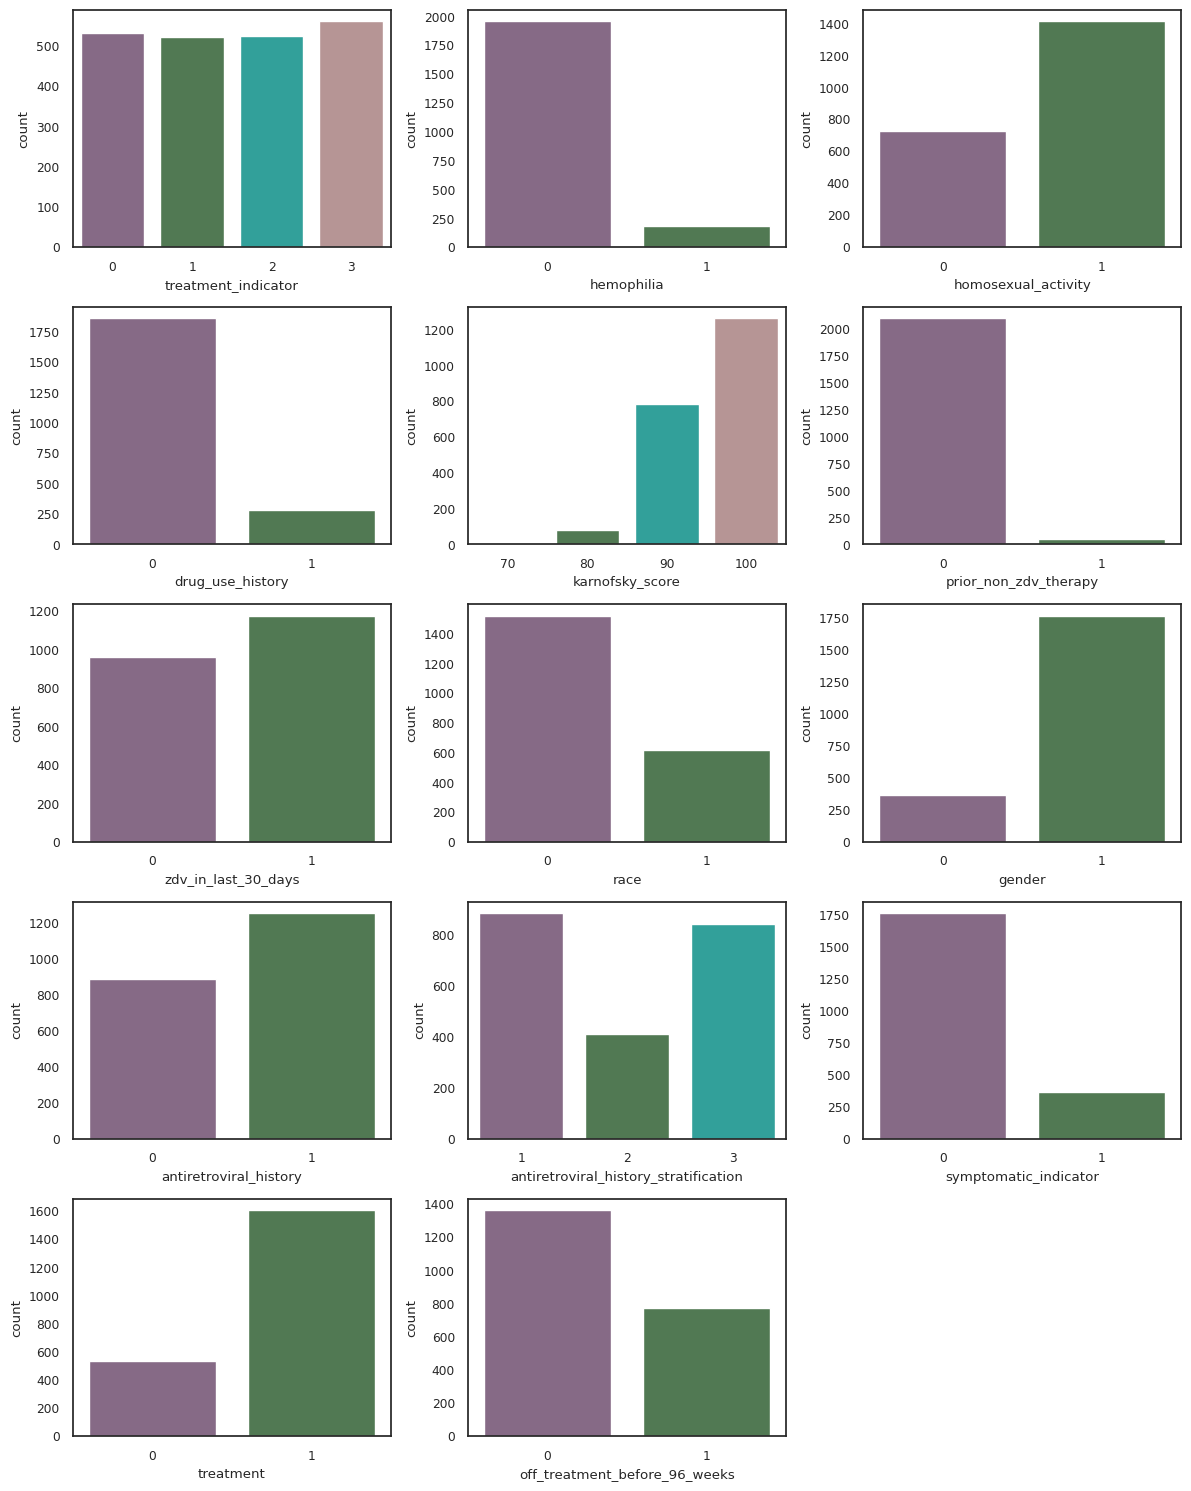

In [ ]:
cat_cols = ["treatment_indicator", "hemophilia", "homosexual_activity", "drug_use_history", "karnofsky_score", "prior_non_zdv_therapy",
            "zdv_in_last_30_days", "race", "gender", "antiretroviral_history", "antiretroviral_history_stratification", "symptomatic_indicator", "treatment",
            "off_treatment_before_96_weeks"] # Updated column names to reflect changes made with data.rename
clr = ["#8b658b", "#4a804d", "#20b2aa", "#bc8f8f", "#6495ed"]
plt.figure(figsize=(12,15))
for i, col in enumerate(cat_cols):
    plt.subplot(5,3, i+1)
    sns.barplot(x=data[col].value_counts().index, y=data[col].value_counts(), palette=clr)
plt.tight_layout()
plt.show()

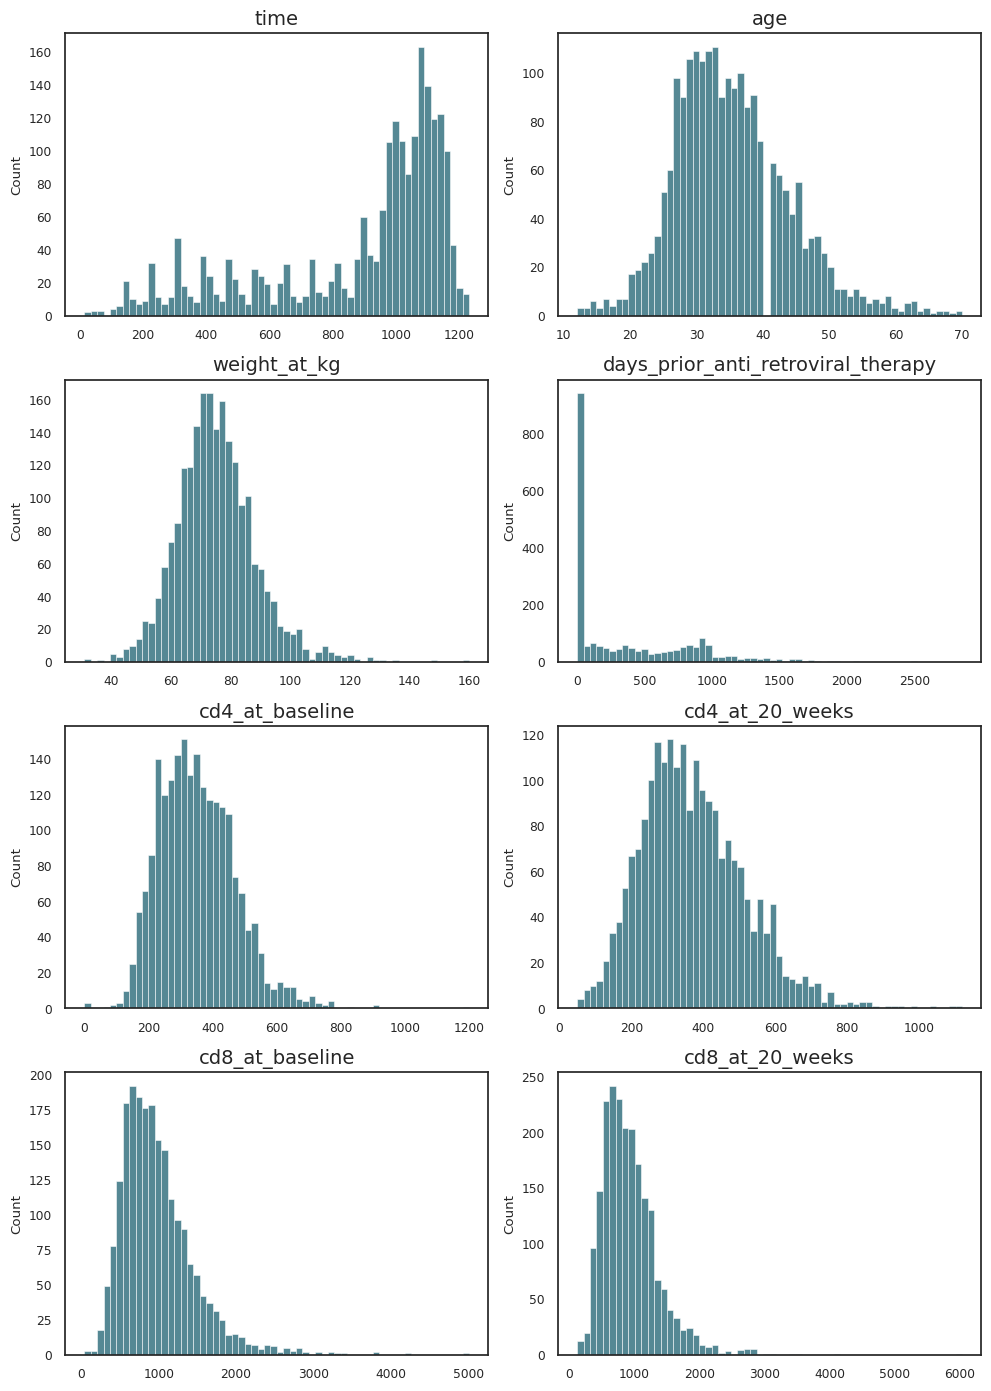

In [ ]:
num_cols = ['time', 'age', 'weight_at_kg', 'days_prior_anti_retroviral_therapy', 'cd4_at_baseline',
            'cd4_at_20_weeks', 'cd8_at_baseline', 'cd8_at_20_weeks']

sns.set(font_scale=0.8)
sns.set_style("white")
plt.figure(figsize=(10,14))
for i, col in enumerate(num_cols):
    plt.subplot(4,2, i+1)
    sns.histplot(data[col], bins=60, color="#1c6071")
    plt.xlabel("")
    plt.title(col, fontsize=14)
plt.tight_layout()
plt.show()

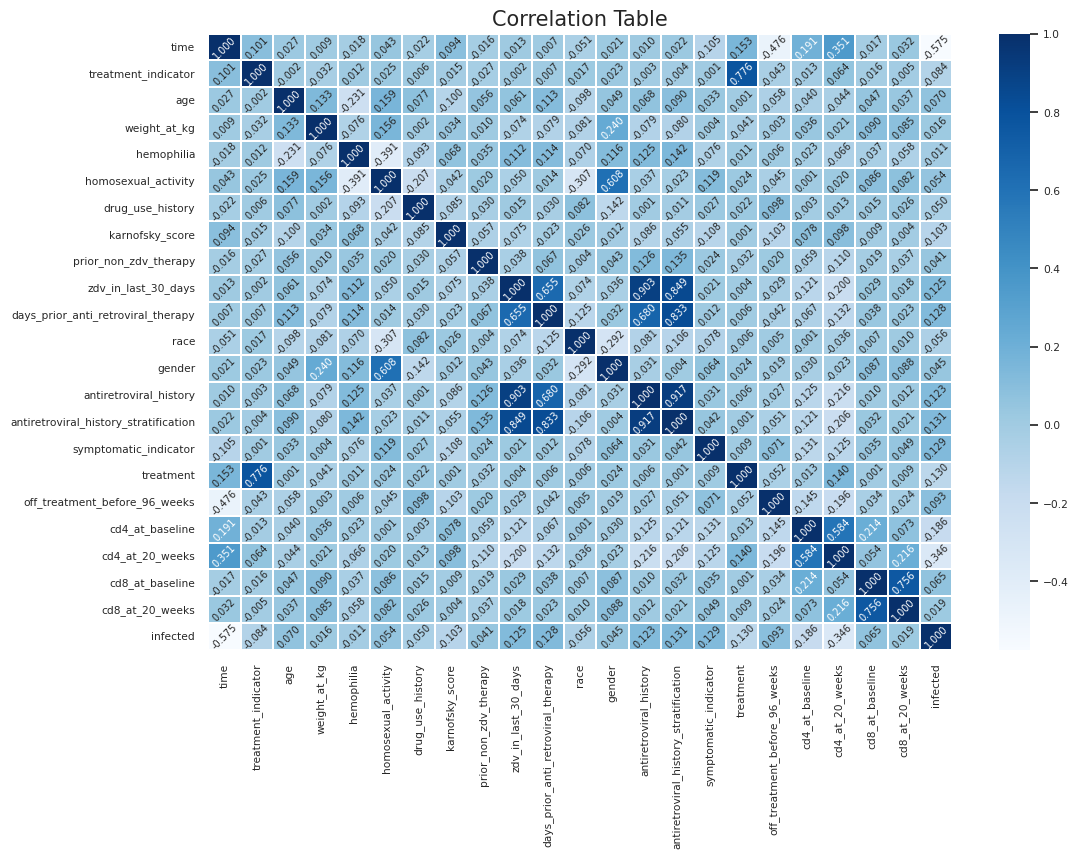

In [ ]:
plt.figure(figsize=(12,8))
sns.set(font_scale=0.7)
sns.heatmap(data.corr(), annot=True, annot_kws={"rotation":45, "fontsize":7}, fmt=".3f", linewidths=0.1, cmap="Blues")
plt.title("Correlation Table", fontsize=15)
plt.show()

In [ ]:
# Memanggil fungsi grab_col_names yang telah didefinisikan untuk memisahkan kolom-kolom dalam dataframe menjadi tiga kategori berdasarkan tipe data dan karakteristik distribusinya
cat_cols, num_cols, cat_but_car = grab_col_names(data)

Jumlah observasi: 2139
Jumlah variabel: 23
Kolom kategorikal: 15
Kolom Numerik: 8
Kategori tapi kardinal: 0
Numerik tapi kategorikal: 15


### Essay
1. terdapat nama kolom yang sulit dibaca
2. terdapat nilai dalam kolom yang menyulitkan ketika dibaca (akan tetapi bila diubah akan menambah pekerjaan dalam modeling)
3. semua nilai dalam kolom data bertipe numerik
4. walaupun ada kolom katergorikal tapi nilainya bertipe numerik

## 4) Menentukan Object Data <a class="anchor" id="h4"></a>

In [ ]:
# Menampilkan 5 baris pertama dari dataframe data
data.head()

,time,treatment_indicator,age,weight_at_kg,hemophilia,homosexual_activity,drug_use_history,karnofsky_score,prior_non_zdv_therapy,zdv_in_last_30_days,days_prior_anti_retroviral_therapy,race,gender,antiretroviral_history,antiretroviral_history_stratification,symptomatic_indicator,treatment,off_treatment_before_96_weeks,cd4_at_baseline,cd4_at_20_weeks,cd8_at_baseline,cd8_at_20_weeks,infected
0,948,2,48,89.8128,0,0,0,100,0,0,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [ ]:
# Menampilkan 5 baris terakhir dari dataframe data
data.tail()

,time,treatment_indicator,age,weight_at_kg,hemophilia,homosexual_activity,drug_use_history,karnofsky_score,prior_non_zdv_therapy,zdv_in_last_30_days,days_prior_anti_retroviral_therapy,race,gender,antiretroviral_history,antiretroviral_history_stratification,symptomatic_indicator,treatment,off_treatment_before_96_weeks,cd4_at_baseline,cd4_at_20_weeks,cd8_at_baseline,cd8_at_20_weeks,infected
2134,1091,3,21,53.2980,1,0,0,100,0,1,842,0,1,1,3,0,1,1,152,109,561,720,0
2135,395,0,17,102.9672,1,0,0,100,0,1,417,1,1,1,3,0,0,1,373,218,1759,1030,0
2136,1104,2,53,69.8544,1,1,0,90,0,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0
2137,465,0,14,60.0000,1,0,0,100,0,0,0,0,1,0,1,0,0,0,166,169,999,1838,1
2138,1045,3,45,77.3000,1,0,0,100,0,0,0,0,1,0,1,0,1,0,911,930,885,526,0


In [ ]:
# Menampilkan informasi ringkas tentang dataframe data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   time                                   2139 non-null   int64  
 1   treatment_indicator                    2139 non-null   int64  
 2   age                                    2139 non-null   int64  
 3   weight_at_kg                           2139 non-null   float64
 4   hemophilia                             2139 non-null   int64  
 5   homosexual_activity                    2139 non-null   int64  
 6   drug_use_history                       2139 non-null   int64  
 7   karnofsky_score                        2139 non-null   int64  
 8   prior_non_zdv_therapy                  2139 non-null   int64  
 9   zdv_in_last_30_days                    2139 non-null   int64  
 10  days_prior_anti_retroviral_therapy     2139 non-null   int64  
 11  race

menghitung jumlah fitur pada dataset

In [ ]:
# Menghitung frekuensi kemunculan nilai unik dalam sebuah kolom atau objek Pandas
data.value_counts()

time  treatment_indicator  age  weight_at_kg  hemophilia  homosexual_activity  drug_use_history  karnofsky_score  prior_non_zdv_therapy  zdv_in_last_30_days  days_prior_anti_retroviral_therapy  race  gender  antiretroviral_history  antiretroviral_history_stratification  symptomatic_indicator  treatment  off_treatment_before_96_weeks  cd4_at_baseline  cd4_at_20_weeks  cd8_at_baseline  cd8_at_20_weeks  infected
14    3                    30   64.63800      0           1                    0                 90               0                      0                    0                                   0     1       0                       1                                      1                      1          0                              131              253              227              496              1           1
1068  3                    31   95.50000      0           1                    0                 90               0                      1                    199                                 0     1       1                       2                                      0                      1          0                              302              554              478              595              0           1
1071  0                    29   49.80528      0           0                    0                 100              0                      1                    144                                 0     0       1                       2                                      0                      0          1                              374              380              649              786              0           1
1070  1                    31   56.70000      0           1                    0                 90               0                      1                    822                                 0     1       1                       3                                      0                      1          0                              380              380              1220             1290             0           1
                           29   65.50000      0           1                    0                 100              0                      1                    367                                 1     1       1                       3                                      0                      1          0                              431              420              843              745              0           1
                                                                                                                                                                                                                                                                                                                                                                                                                               ..
889   0                    25   84.18816      0           1                    0                 100              0                      1                    1286                                0     1       1                       3                                      0                      0          1                              336              252              612              477              1           1
888   2                    36   61.68960      0           0                    0                 90               0                      0                    0                                   1     1       0                       1                                      0                      1          1                              416              270              1326             690              0           1
                           27   70.30800      0           1                    0                 100              0                      0                    0                                   1     1       0                       1          

## 5) Membersihkan Data <a class="anchor" id="h5"></a>
Lakukan pembersihan, sesuai dengan dengan hasil eksplorasi mu!

In [ ]:
# Memeriksa missing value pada data
print("Jumlah Missing value: ",data.isna().sum())
# Memeriksa duplikasi pada data
print("Jumlah duplikasi: ",data.duplicated().sum())
data.describe()

Jumlah Missing value:  time                                     0
treatment_indicator                      0
age                                      0
weight_at_kg                             0
hemophilia                               0
homosexual_activity                      0
drug_use_history                         0
karnofsky_score                          0
prior_non_zdv_therapy                    0
zdv_in_last_30_days                      0
days_prior_anti_retroviral_therapy       0
race                                     0
gender                                   0
antiretroviral_history                   0
antiretroviral_history_stratification    0
symptomatic_indicator                    0
treatment                                0
off_treatment_before_96_weeks            0
cd4_at_baseline                          0
cd4_at_20_weeks                          0
cd8_at_baseline                          0
cd8_at_20_weeks                          0
infected                       

,time,treatment_indicator,age,weight_at_kg,hemophilia,homosexual_activity,drug_use_history,karnofsky_score,prior_non_zdv_therapy,zdv_in_last_30_days,days_prior_anti_retroviral_therapy,race,gender,antiretroviral_history,antiretroviral_history_stratification,symptomatic_indicator,treatment,off_treatment_before_96_weeks,cd4_at_baseline,cd4_at_20_weeks,cd8_at_baseline,cd8_at_20_weeks,infected
count,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000
mean,879.098177,1.520804,35.248247,75.125311,0.084151,0.661057,0.131370,95.446470,0.021973,0.550257,379.175783,0.288453,0.827957,0.585788,1.979897,0.172978,0.751286,0.362786,350.501169,371.307153,986.627396,935.369799,0.243572
std,292.274324,1.127890,8.709026,13.263164,0.277680,0.473461,0.337883,5.900985,0.146629,0.497584,468.657526,0.453149,0.377506,0.492701,0.899053,0.378317,0.432369,0.480916,118.573863,144.634909,480.197750,444.976051,0.429338
min,14.000000,0.000000,12.000000,31.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,49.000000,40.000000,124.000000,0.000000
25%,727.000000,1.000000,29.000000,66.679200,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,263.500000,269.000000,654.000000,631.500000,0.000000
50%,997.000000,2.000000,34.000000,74.390400,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,142.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000,340.000000,353.000000,893.000000,865.000000,0.000000
75%,1091.000000,3.000000,40.000000,82.555200,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,739.500000,1.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,423.000000,460.000000,1207.000000,1146.500000,0.000000
max,1231.000000,3.000000,70.000000,159.939360,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,2851.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1199.000000,1119.000000,5011.000000,6035.000000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   time                                   2139 non-null   int64  
 1   treatment_indicator                    2139 non-null   int64  
 2   age                                    2139 non-null   int64  
 3   weight_at_kg                           2139 non-null   float64
 4   hemophilia                             2139 non-null   int64  
 5   homosexual_activity                    2139 non-null   int64  
 6   drug_use_history                       2139 non-null   int64  
 7   karnofsky_score                        2139 non-null   int64  
 8   prior_non_zdv_therapy                  2139 non-null   int64  
 9   zdv_in_last_30_days                    2139 non-null   int64  
 10  days_prior_anti_retroviral_therapy     2139 non-null   int64  
 11  race

In [ ]:
data_iqr = data.copy() # Salin dataset asli

for col in data.select_dtypes(include=['float64']).columns:
    Q1 = data[col].quantile(0.25) # Kuartil pertama (25%)
    Q3 = data[col].quantile(0.75) # Kuartil ketiga (75%)
    IQR = Q3 - Q1 # Hitung IQR (Interquartile Range)
    lower_bound = Q1 - 1.5 * IQR # Tentukan batas bawah untuk outlier
    upper_bound = Q3 + 1.5 * IQR # Tentukan batas atas untuk outlier

    # Ganti outliers dengan batas bawah/atas
    data_iqr[col] = data[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    print(f"Outliers pada kolom '{col}' telah ditangani menggunakan metode IQR.")

Outliers pada kolom 'weight_at_kg' telah ditangani menggunakan metode IQR.


In [ ]:
#Memperbaiki nilai pada kolom month
# hemophilia_name = {
#     0: 'no',
#     1: 'yes'
# }
# data['hemophilia'] = data['hemophilia'].map(hemophilia_name)

In [ ]:
# hemophilia_name = {
#     0: 'no',
#     1: 'yes'
# }
# data['hemophilia'] = data['hemophilia'].map(hemophilia_name)

In [ ]:
# prompt: simpan dataset yang sudah dibersihkan di dataset_clean

# Simpan dataset yang sudah dibersihkan ke file CSV
#data_iqr.to_csv('dataset_clean.csv', index=False)

In [ ]:
# Lakukan cleaning data disini
#dataset_clean =

### Essay
1. mengubah nama kolom agar lebih mudah dibaca
2. mengecek apakah terdapat missing value dan duplikat(ternyata tidak ada)

## 6) Konstruksi Data <a class="anchor" id="h6"></a>

Dalam tahap ini Konstruksi data salah satu tujuannya yaitu untuk menyesuaikan semua tipe data yang ada di dalam dataset. Namun pada tahap ini dataset sudah memiliki tipe data yang sesuai sehingga tidak perlu dilakukan penyesuaian kembali

In [ ]:
# Memberikan informasi detail tentang struktur dataframe
data.info() # data_clean sebagai dataset yang telah bersih

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   time                                   2139 non-null   int64  
 1   treatment_indicator                    2139 non-null   int64  
 2   age                                    2139 non-null   int64  
 3   weight_at_kg                           2139 non-null   float64
 4   hemophilia                             2139 non-null   int64  
 5   homosexual_activity                    2139 non-null   int64  
 6   drug_use_history                       2139 non-null   int64  
 7   karnofsky_score                        2139 non-null   int64  
 8   prior_non_zdv_therapy                  2139 non-null   int64  
 9   zdv_in_last_30_days                    2139 non-null   int64  
 10  days_prior_anti_retroviral_therapy     2139 non-null   int64  
 11  race

In [ ]:
# Memberikan ringkasan statistik deskriptif dari kolom numerik
data.describe()

,time,treatment_indicator,age,weight_at_kg,hemophilia,homosexual_activity,drug_use_history,karnofsky_score,prior_non_zdv_therapy,zdv_in_last_30_days,days_prior_anti_retroviral_therapy,race,gender,antiretroviral_history,antiretroviral_history_stratification,symptomatic_indicator,treatment,off_treatment_before_96_weeks,cd4_at_baseline,cd4_at_20_weeks,cd8_at_baseline,cd8_at_20_weeks,infected
count,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000
mean,879.098177,1.520804,35.248247,75.125311,0.084151,0.661057,0.131370,95.446470,0.021973,0.550257,379.175783,0.288453,0.827957,0.585788,1.979897,0.172978,0.751286,0.362786,350.501169,371.307153,986.627396,935.369799,0.243572
std,292.274324,1.127890,8.709026,13.263164,0.277680,0.473461,0.337883,5.900985,0.146629,0.497584,468.657526,0.453149,0.377506,0.492701,0.899053,0.378317,0.432369,0.480916,118.573863,144.634909,480.197750,444.976051,0.429338
min,14.000000,0.000000,12.000000,31.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,49.000000,40.000000,124.000000,0.000000
25%,727.000000,1.000000,29.000000,66.679200,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,263.500000,269.000000,654.000000,631.500000,0.000000
50%,997.000000,2.000000,34.000000,74.390400,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,142.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000,340.000000,353.000000,893.000000,865.000000,0.000000
75%,1091.000000,3.000000,40.000000,82.555200,0.000000,1.000000,0.000000,100.000000,0.000000,1.000000,739.500000,1.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,423.000000,460.000000,1207.000000,1146.500000,0.000000
max,1231.000000,3.000000,70.000000,159.939360,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,2851.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1199.000000,1119.000000,5011.000000,6035.000000,1.000000


In [ ]:
# Menampilkan 5 baris pertama
data.head(5)

,time,treatment_indicator,age,weight_at_kg,hemophilia,homosexual_activity,drug_use_history,karnofsky_score,prior_non_zdv_therapy,zdv_in_last_30_days,days_prior_anti_retroviral_therapy,race,gender,antiretroviral_history,antiretroviral_history_stratification,symptomatic_indicator,treatment,off_treatment_before_96_weeks,cd4_at_baseline,cd4_at_20_weeks,cd8_at_baseline,cd8_at_20_weeks,infected
0,948,2,48,89.8128,0,0,0,100,0,0,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


## 7) Menentukan Label <a class="anchor" id="h7"></a>

Setelah selesai menyesuaikan kita pisah dataset dan label

In [ ]:
# Memisahkan fitur (X) dan target (y) dalam dataset
X = data.drop("infected", axis = 1)
y = data["infected"]

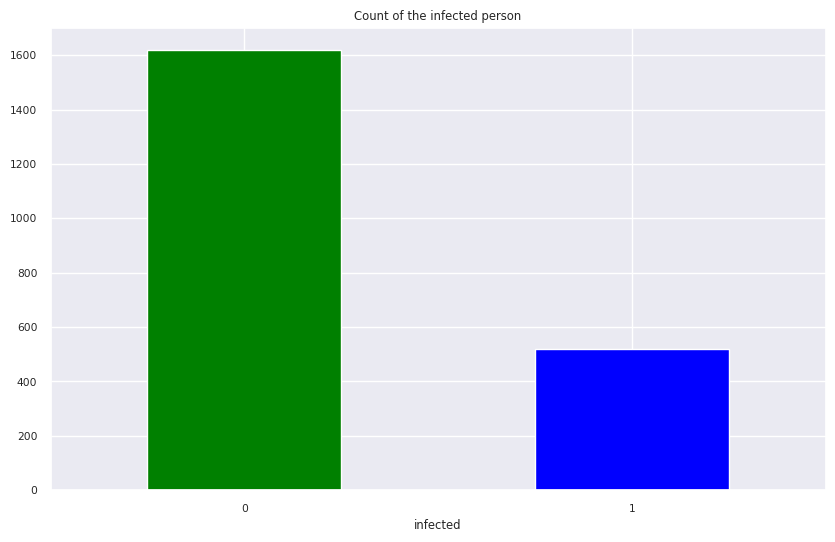

In [ ]:
# Membuat visualisasi berupa diagram batang (bar plot) yang menunjukkan jumlah individu yang termasuk dalam masing-masing kategori pada kolom infected
data['infected'].value_counts().plot(kind='bar',figsize=(10,6),color=['green','blue'])
plt.title("Count of the infected person")
plt.xticks(rotation=0);

Pada Grafik diatas menunjukan bahwa persebaran jumlah target tidak seimbang oleh karena itu perlu diseimbangkan terlebih dahulu. Menyeimbangkan target ada 2 cara yaitu oversampling dan undersampling. oversampling dilakukan jika jumlah dataset sedikit sedangkan undersampling dilakukan jika jumlah data terlalu banyak.
<br>
Disini kita akan melakukan oversampling dikarenakan jumlah data kita tidak banyak. Salah satu metode yang Oversampling yang akan kita gunakan adalah SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE # Library untuk membantu oversampling dengan teknik SMOTE

In [ ]:
smote = SMOTE(random_state=42) # Inisialisasi SMOTE
X_smote_resampled, y_smote_resampled = smote.fit_resample(X, y) # Mengaplikasikan oversampling pada dataset

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


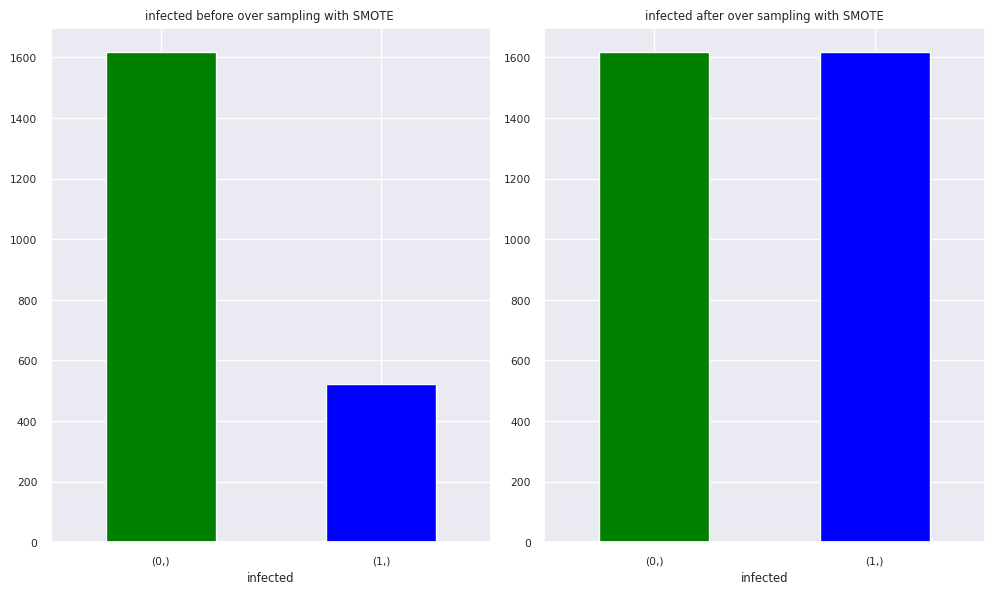

In [ ]:
plt.figure(figsize=(12, 4)) # Membuat sebuah figure (gambar) baru dengan ukuran 12x4 inci

new_df1 = pd.DataFrame(data=y) # Membuat DataFrame baru, new_df1

plt.subplot(1, 2, 1)
new_df1.value_counts().plot(kind='bar',figsize=(10,6),color=['green','blue'])
plt.title("infected before over sampling with SMOTE ")
plt.xticks(rotation=0);


plt.subplot(1, 2, 2) # Membuat subplot pertama dengan layout 1 baris dan 2 kolom
new_df2 = pd.DataFrame(data=y_smote_resampled)


new_df2.value_counts().plot(kind='bar',figsize=(10,6),color=['green','blue']) # Menghitung frekuensi masing-masing kategori (0 dan 1), membuat diagram batang (bar plot) berdasarkan frekuensi kategori
plt.title("infected after over sampling with SMOTE") # Memberikan judul pada subplot pertama
plt.xticks(rotation=0); # Menetapkan label sumbu-x (kategori 0 dan 1) untuk tetap dalam posisi horizontal

plt.tight_layout() # Mengatur layout agar subplot tidak saling tumpang tindih
plt.show() # Menampilkan kedua plot dalam satu figure

Lakukan pembagian data menjadi latih dan data testing

In [ ]:
from sklearn.model_selection import train_test_split # Library untuk membantu memisahkan data menjadi dataset latih dan dataset validasi
X_train, X_test, y_train, y_test = train_test_split(X_smote_resampled, y_smote_resampled, test_size=0.2, random_state=42,stratify=y_smote_resampled) # 80% data latih, 20% data test

## 8) Model <a class="anchor" id="h7"></a>
Gunakan sebuah model klaisifikasi sebagai algoritma yang disarankan untuk pelatihan!

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Nama Model
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)
svm = SVC(random_state=42)
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()

models = {
    "Naive Bayes": nb,
    "Random Forest": rf,
    "SVM": svm,
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "K-Nearest Neighbors": knn,

}

###Naive Bayes

In [ ]:
nb.fit(X_train, y_train)

nb_y_pred = nb.predict(X_test)
accuracy_nb = round(accuracy_score(y_test, nb_y_pred), 3)

print(confusion_matrix(y_test, nb_y_pred))

print(classification_report(y_test, nb_y_pred))

[[247  77]
 [ 45 279]]
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       324
           1       0.78      0.86      0.82       324

    accuracy                           0.81       648
   macro avg       0.81      0.81      0.81       648
weighted avg       0.81      0.81      0.81       648



### Random Forest

In [ ]:
rf.fit(X_train, y_train)

rf_y_pred = rf.predict(X_test)
accuracy_rf = round(accuracy_score(y_test, rf_y_pred), 3)

print(confusion_matrix(y_test, rf_y_pred))

print(classification_report(y_test, rf_y_pred))

[[304  20]
 [ 17 307]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       324
           1       0.94      0.95      0.94       324

    accuracy                           0.94       648
   macro avg       0.94      0.94      0.94       648
weighted avg       0.94      0.94      0.94       648



###SVM

In [ ]:
svm.fit(X_train, y_train)

svm_y_pred = svm.predict(X_test)
accuracy_svm = round(accuracy_score(y_test, svm_y_pred), 3)

print(confusion_matrix(y_test, svm_y_pred))

print(classification_report(y_test, svm_y_pred))

[[273  51]
 [ 37 287]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       324
           1       0.85      0.89      0.87       324

    accuracy                           0.86       648
   macro avg       0.86      0.86      0.86       648
weighted avg       0.86      0.86      0.86       648



### Logistic regression

In [ ]:
lr.fit(X_train, y_train)

lr_y_pred = lr.predict(X_test)
accuracy_lr = round(accuracy_score(y_test, lr_y_pred), 3)

print(confusion_matrix(y_test, lr_y_pred))

print(classification_report(y_test, lr_y_pred))

[[273  51]
 [ 53 271]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       324
           1       0.84      0.84      0.84       324

    accuracy                           0.84       648
   macro avg       0.84      0.84      0.84       648
weighted avg       0.84      0.84      0.84       648



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###Decisson tree

In [ ]:
dt.fit(X_train, y_train)

dt_y_pred = dt.predict(X_test)
accuracy_dt = round(accuracy_score(y_test, dt_y_pred), 3)

print(confusion_matrix(y_test, dt_y_pred))

print(classification_report(y_test, dt_y_pred))

[[291  33]
 [ 25 299]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       324
           1       0.90      0.92      0.91       324

    accuracy                           0.91       648
   macro avg       0.91      0.91      0.91       648
weighted avg       0.91      0.91      0.91       648



### KNN

In [ ]:
knn.fit(X_train, y_train)

knn_y_pred = knn.predict(X_test)
accuracy_knn = round(accuracy_score(y_test, knn_y_pred), 3)

print(confusion_matrix(y_test, knn_y_pred))

print(classification_report(y_test, knn_y_pred))

[[270  54]
 [ 13 311]]
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       324
           1       0.85      0.96      0.90       324

    accuracy                           0.90       648
   macro avg       0.90      0.90      0.90       648
weighted avg       0.90      0.90      0.90       648



### Essay
Dari hasil model yang digunakan di atas bisa terlihat perbandingannya

## 9) Evaluasi <a class="anchor" id="h9"></a>
Evaluasi performa model yang telah kamu latih!

<ipython-input-92-c2a6ffa7dd51>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


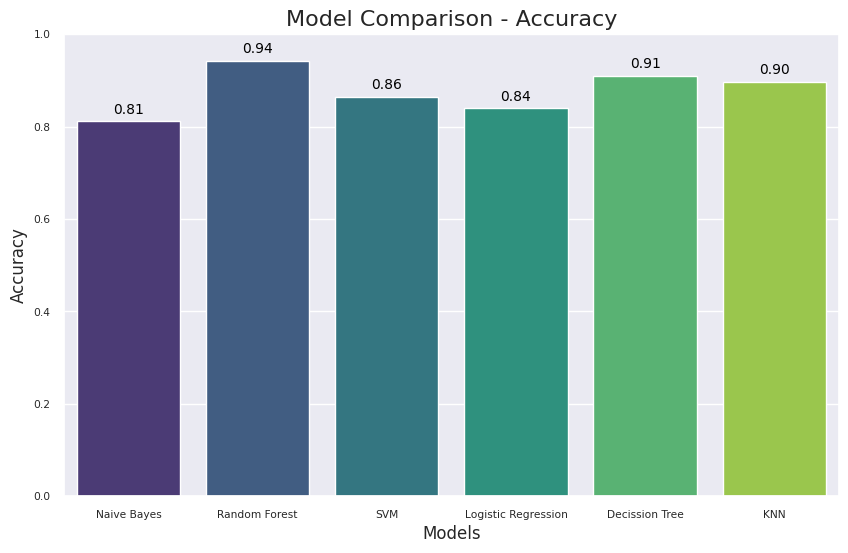

In [ ]:
models = ['Naive Bayes', 'Random Forest', 'SVM', 'Logistic Regression', 'Decission Tree', 'KNN']
accuracies = [
    accuracy_score(y_test, nb_y_pred),
    accuracy_score(y_test, rf_y_pred),
    accuracy_score(y_test, svm_y_pred),
    accuracy_score(y_test, lr_y_pred),
    accuracy_score(y_test, dt_y_pred),
    accuracy_score(y_test, knn_y_pred)
]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.title('Model Comparison - Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0, 1)
plt.show()

### Essay
bisa terlihat hasil dari perbandingan metode yang digunakan diatas
1. model dengan akurasi tertinggi adalah random forest
2. model dengan akurasi terendah adalah svm